In [2]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore') # Hides minor excel reading warnings

print("--- STEP 1: LOADING & CLEANING RAINFALL DATA ---")

# 1. Load the rainfall file and specific sheet
filepath = '/kaggle/input/datasets/shishirpuri/kamala-master-model/Metrology/daily rf.xlsx'
sheet_name = '24h accumulated Precipitation '
rf_df = pd.read_excel(filepath, sheet_name=sheet_name)

# 2. Date column lai datetime ma convert garne ra Time hatayera Date matra rakhne
rf_df['Time (UTC)'] = pd.to_datetime(rf_df['Time (UTC)'], errors='coerce')
rf_df['Time (UTC)'] = rf_df['Time (UTC)'].dt.normalize() 

# 3. Date lai Index banaune ra 2022 dekhi ko data matra line
rf_df.set_index('Time (UTC)', inplace=True)
rf_df = rf_df.loc['2022-01-01':]

# 4. Yadi kunai din 2 choti data aayeko cha bhane teslai mean garera eutai banaune
rf_df = rf_df.groupby(rf_df.index).mean(numeric_only=True)

# 5. Hamro 8 wata required stations matra select garne
rf_cols = [
    'Sindhuli Madhi (mm)', 'Bahun Tilpung (mm)', 'Tulsi (mm)', 'Chisapani Bazar (mm)', 
    'Janakpur Airport (mm)', 'Hardinath (mm)', 'Lahan (mm)', 'Siraha (mm)'
]
rf_data = rf_df[rf_cols]

# 6. Column ko naam clean ra sajilo banaune
rf_data.columns = [
    'Rain_Sindhuli', 'Rain_BahunTilpung', 'Rain_Tulsi', 'Rain_Chisapani', 
    'Rain_Janakpur', 'Rain_Hardinath', 'Rain_Lahan', 'Rain_Siraha'
]

print("✅ Rainfall Data Loaded Successfully!")
print("-" * 50)
print(f"Shape: {rf_data.shape} (Days, Stations)")
print("\nMissing Values (NaNs) per station before any interpolation:")
print(rf_data.isna().sum())
print("-" * 50)
print("\nFirst 3 rows preview:")
print(rf_data.head(3))

--- STEP 1: LOADING & CLEANING RAINFALL DATA ---
✅ Rainfall Data Loaded Successfully!
--------------------------------------------------
Shape: (1627, 8) (Days, Stations)

Missing Values (NaNs) per station before any interpolation:
Rain_Sindhuli         0
Rain_BahunTilpung    32
Rain_Tulsi            0
Rain_Chisapani        0
Rain_Janakpur         0
Rain_Hardinath        1
Rain_Lahan            1
Rain_Siraha           2
dtype: int64
--------------------------------------------------

First 3 rows preview:
            Rain_Sindhuli  Rain_BahunTilpung  Rain_Tulsi  Rain_Chisapani  \
Time (UTC)                                                                 
2022-01-01            0.0                0.0         0.0             0.0   
2022-01-02            0.0                0.0         0.0             0.0   
2022-01-03            0.0                0.0         0.0             0.0   

            Rain_Janakpur  Rain_Hardinath  Rain_Lahan  Rain_Siraha  
Time (UTC)                             

In [3]:
rf_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1627 entries, 2022-01-01 to 2026-06-15
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Rain_Sindhuli      1627 non-null   float64
 1   Rain_BahunTilpung  1595 non-null   float64
 2   Rain_Tulsi         1627 non-null   float64
 3   Rain_Chisapani     1627 non-null   float64
 4   Rain_Janakpur      1627 non-null   float64
 5   Rain_Hardinath     1626 non-null   float64
 6   Rain_Lahan         1626 non-null   float64
 7   Rain_Siraha        1625 non-null   float64
dtypes: float64(8)
memory usage: 114.4 KB


In [4]:
print("--- STEP 2: CHOPPING DATA TO MATCH KAMALA TIMELINE ---")

# Define target timeframe with a slight lookback buffer for sequence creation later
START_DATE = '2022-05-20' # Buffer of ~18 days before Kamala data starts (2022-06-08)
END_DATE = '2025-11-05'   # Exact end date of Kamala data

# Chop off the unnecessary past and future data
rf_data_aligned = rf_data.loc[START_DATE:END_DATE]

print(f"✅ Data cropped successfully from {START_DATE} to {END_DATE}")
print("-" * 50)
print(f"New Shape: {rf_data_aligned.shape} (Days, Stations)")
print("\nMissing Values (NaNs) after timeline crop:")
print(rf_data_aligned.isna().sum())
print("-" * 50)

--- STEP 2: CHOPPING DATA TO MATCH KAMALA TIMELINE ---
✅ Data cropped successfully from 2022-05-20 to 2025-11-05
--------------------------------------------------
New Shape: (1266, 8) (Days, Stations)

Missing Values (NaNs) after timeline crop:
Rain_Sindhuli        0
Rain_BahunTilpung    0
Rain_Tulsi           0
Rain_Chisapani       0
Rain_Janakpur        0
Rain_Hardinath       0
Rain_Lahan           0
Rain_Siraha          0
dtype: int64
--------------------------------------------------


--- STEP 3: GRAPHICAL EVALUATION (RAINFALL EDA) ---


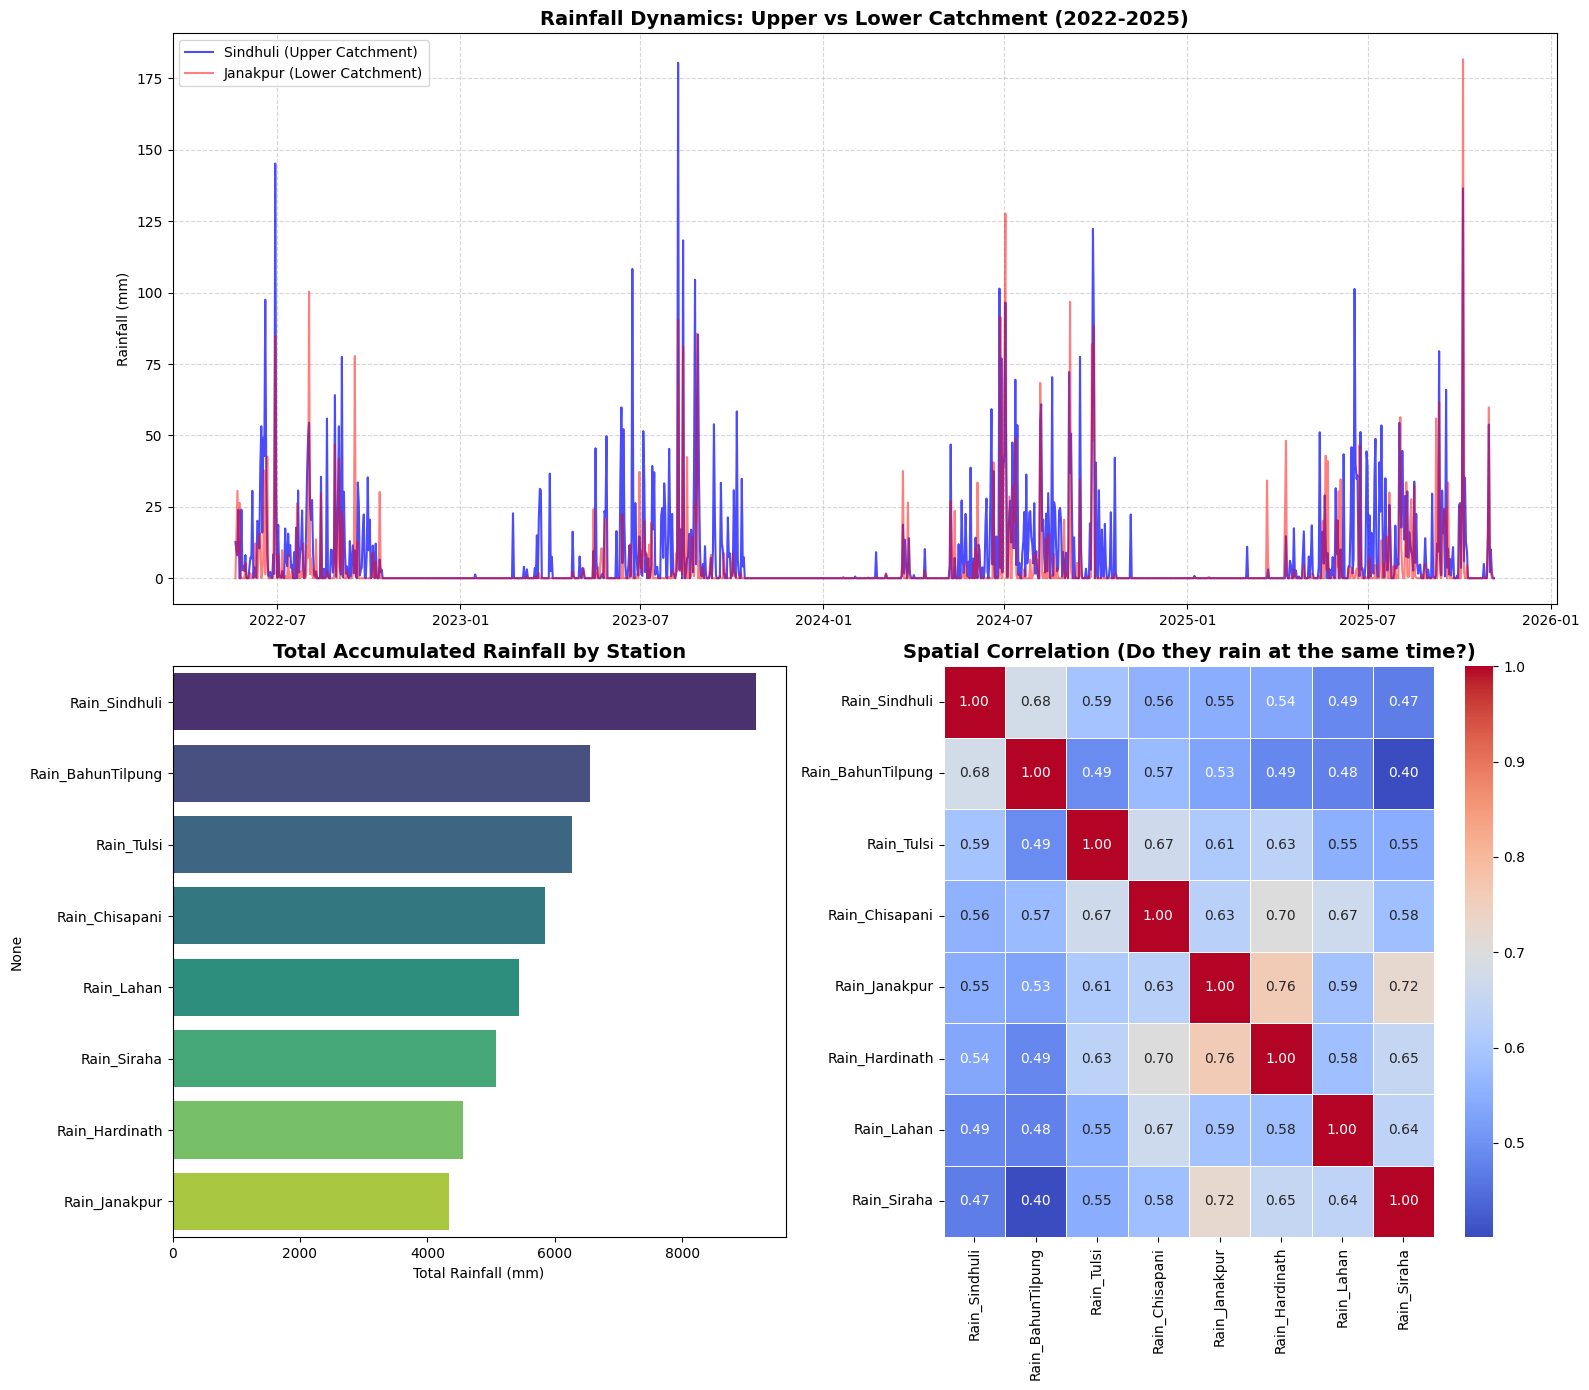

✅ EDA Plots Generated Successfully!


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- STEP 3: GRAPHICAL EVALUATION (RAINFALL EDA) ---")

# Setup the figure canvas
fig = plt.figure(figsize=(16, 14))

# -------------------------------------------------------------
# PLOT 1: Time Series Comparison (Upper vs Lower Catchment)
# -------------------------------------------------------------
ax1 = plt.subplot(2, 1, 1) # Top row, spanning full width
# We plot Sindhuli (Mountain/Upper) and Janakpur (Terai/Lower) to see lag
ax1.plot(rf_data_aligned.index, rf_data_aligned['Rain_Sindhuli'], label='Sindhuli (Upper Catchment)', color='blue', alpha=0.7)
ax1.plot(rf_data_aligned.index, rf_data_aligned['Rain_Janakpur'], label='Janakpur (Lower Catchment)', color='red', alpha=0.5)

ax1.set_title('Rainfall Dynamics: Upper vs Lower Catchment (2022-2025)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Rainfall (mm)')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.5)

# -------------------------------------------------------------
# PLOT 2: Total Accumulated Rainfall (Bar Chart)
# -------------------------------------------------------------
ax2 = plt.subplot(2, 2, 3) # Bottom row, left side
total_rain = rf_data_aligned.sum().sort_values(ascending=False)

sns.barplot(x=total_rain.values, y=total_rain.index, palette='viridis', ax=ax2)
ax2.set_title('Total Accumulated Rainfall by Station', fontsize=14, fontweight='bold')
ax2.set_xlabel('Total Rainfall (mm)')

# -------------------------------------------------------------
# PLOT 3: Spatial Correlation Heatmap
# -------------------------------------------------------------
ax3 = plt.subplot(2, 2, 4) # Bottom row, right side
corr_matrix = rf_data_aligned.corr()

# Heatmap shows how closely stations follow the same rain patterns
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, ax=ax3)
ax3.set_title('Spatial Correlation (Do they rain at the same time?)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("✅ EDA Plots Generated Successfully!")